# Hypsometric map of South Africa

## Introduction

This page is a revisit of a hypsometric map I once did of South Africa. The map visualises various geographical features of South Africa, including elevation data, rivers, mountain ranges, provincial boundaries, and coastal features such as the Agulhas Bank and Benguela Upwelling.

## Features
- **Elevation Data**: Visualized using vibrant hypsometric colors ranging from deep ocean depths to the highest peaks.
- **Rivers and Provinces**: Includes South African rivers and provincial boundaries.
- **Coastal Features**: Highlights the Agulhas Bank and Benguela Upwelling regions.
- **Mountain Ranges**: Marks major mountain ranges with labeled points.
- **Neighboring Countries**: Includes labels and borders for neighboring countries.
- **Annotations**: Labels for the Atlantic and Indian Oceans.

## Libraries Used
The following R libraries were used in this script:
- `tidyverse` for data manipulation and visualization
- `scales` for scaling functions
- `ggspatial` for spatial visualization
- `rnaturalearth` and `rnaturalearthdata` for Natural Earth map data
- `sf` for handling spatial features
- `raster` for raster data manipulation
- `elevatr` for elevation data
- `ggrepel` for repulsive text and label geoms
- `rnaturalearthhires` for high-resolution map data
- `ggnewscale` for multiple scales in `ggplot2`


Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [17]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

options(
  repr.plot.width  = 10,
  repr.plot.height = 7,
  repr.plot.res    = 150
)

# These options center our plots and gives them a better resolution than default. 
# These options are only for jupyter notebook. Ignore you use R and RStudio.

### Install libraries

First and foremost, we have to install all the packages listed above in order to access the geospatial data used in this workflow.

In [ ]:
install.packages("scales")
install.packages("ggspatial")
install.packages("sf")
install.packages("raster")
install.packages("elevatr")
install.packages("ggrepel")
install.packages("rnaturalearth")
install.packages("rnaturalearthdata")
install.packages("ggnewscale")

This the list of all these libraries, there is one troublesome package that will refuse to install the normal way - **rnaturalearthhires**. This packages is not on CRAN, which is why a plain `install.packages()` fails. It lives on GitHub and needs to be installed from its source repository with its dependencies resolved explicitly. There are a few steps to take in order to instll it and I will show you below:

First, make sure you can install packages from GitHub. You can do so by installing the **remotes** package (or use devtools; remotes is lighter and sufficient)

In [ ]:
install.packages("remotes")

Once that has been installed, install rnaturalhires directly from its repository:

In [6]:
remotes::install_github("ropensci/rnaturalearthhires")

Using GitHub PAT from the git credential store.


Running `R CMD build`...



* checking for file 'C:\Users\pheme\AppData\Local\Temp\RtmpCMfvNd\remotes290c763a690b\ropensci-rnaturalearthhires-e4736f6/DESCRIPTION' ... OK
* preparing 'rnaturalearthhires':
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building 'rnaturalearthhires_1.0.0.9000.tar.gz'


Installing package into 'C:/Users/pheme/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



That is the entire installation step of **rnaturalearthhires**. After installation, we can now load all packages and begin.

In [10]:
library(tidyverse)            # Data manipulation and visualization
library(scales)               # Scale functions for visualization
library(ggspatial)            # Spatial data visualization
library(sf)                   # Simple Features for R
library(raster)               # Raster data manipulation
library(elevatr)              # Get elevation data
library(ggrepel)              # Repulsive text and label geoms
library(rnaturalearth)        # Natural Earth map data
library(rnaturalearthdata)    # Additional Natural Earth map data
library(rnaturalearthhires)   # High resolution Natural Earth data
library(ggnewscale)           # Multiple fill and color scales in ggplot2

# Disable S2 spherical geometry
sf_use_s2(FALSE)

Spherical geometry (s2) switched off



### Data Preparation

In this next step, we will be preparing our data. This includes defining our country of interest's bounding box, adding neighbouring countries's names, South Africa's provinces, capital city names and coordinates, elevation, etc.

In [12]:
# Define bounding box for South Africa
xmin <- 14.5
xmax <- 35.5
ymin <- -37.5
ymax <- -22.0
south_africa_bbox <- data.frame(x = c(xmin, xmax), y = c(ymin, ymax))

# Get neighboring countries of South Africa
neighboring_countries <- ne_countries(scale = "medium", returnclass = "sf") %>% 
  filter(name %in% c("Namibia", "Botswana", "Zimbabwe", "Mozambique", "Lesotho", "Eswatini"))

# Get South African provinces
sa_prov <- ne_states(country = "South Africa", returnclass = "sf")

This step involves retrieving elevation data using the **elevatr** package. The elevation data in **elevatr** is NASA's SRTM Elevation Data. The `z = 5` determines the quality of the elevation data. You can replace 5 with any value you desire, with the quality increasing per increase in the value. When you do change the number, please bear in mind your computer's specifications because higher quality maps use more RAM. They also take longer to be generated.

In [13]:
# Get elevation data for the bounding box
elevation_data <- get_elev_raster(locations = south_africa_bbox, z = 5, prj = "+proj=longlat +datum=WGS84")
elevation_df <- as.data.frame(as(elevation_data, "SpatialPixelsDataFrame"))
colnames(elevation_df) <- c("elevation", "x", "y")

Mosaicing & Projecting

Note: Elevation units are in meters.



In [14]:
# Calculate hillshade from elevation data
slope <- terrain(elevation_data, opt = 'slope')
aspect <- terrain(elevation_data, opt = 'aspect')
hillshade <- hillShade(slope, aspect, angle = 45, direction = 315)
hillshade_df <- as.data.frame(as(hillshade, "SpatialPixelsDataFrame"))
colnames(hillshade_df) <- c("hillshade", "x", "y")

# Get rivers data for South Africa
sa_rivers <- ne_download(scale = "medium", type = "rivers_lake_centerlines", category = "physical", returnclass = "sf") %>% 
  st_crop(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax)

# Define mountain ranges with their coordinates
mountain_ranges <- data.frame(
  name = c("Drakensberg", "Cederberg", "Swartberg", "Magaliesberg", "Cape Fold Belt"),
  lon = c(29.4, 19.0, 22.0, 27.5, 18.5),
  lat = c(-29.5, -32.5, -33.4, -25.5, -33.8)
)

# Define coastal features
agulhas_bank <- data.frame(x = c(20, 20, 25, 25, 20), y = c(-37, -34, -34, -37, -37))
benguela_upwelling <- data.frame(x = c(14, 14, 18, 18, 14), y = c(-30, -27, -27, -30, -30))

# Define hypsometric colors for elevation
hypsometric_colors <- c(
  "#0A2463", "#3E5F8A", "#5B8CBE", "#7BAFD4", "#A7C6E8",  # Water
  "#E8F1D4", "#D4E6B3", "#A7C686", "#8FB05D", "#6B8C3A",  # Lowlands
  "#E3C88F", "#D9B56B", "#C99E4F", "#B58234", "#A66B1E",  # Midlands
  "#BF4E30", "#A73725", "#8C1D1D", "#731F1F",             # Highlands
  "#5D1F1C", "#3D0C02", "#2A0800"                         # Peaks
)

Reading ne_50m_rivers_lake_centerlines.zip from naturalearth...
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
"attribute variables are assumed to be spatially constant throughout all geometries"


The above coastal features are improvised indications of where they are found in the coast of South Africa. 

### Map construction

I will be adding everything all at once into **ggplot2**. If there is a step you do not understand or the code no longer functions the same as when I made this due to depreciation of packages, please do reach out to me on [GitHub](https://github.com/Phemelo-R) under the issues tab.

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Duplicated aesthetics after name standardisation: colour"
Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
"st_point_on_surface may not give correct results for longitude/latitude data"
Scale on map varies by more than 10%, scale bar may be inaccurate



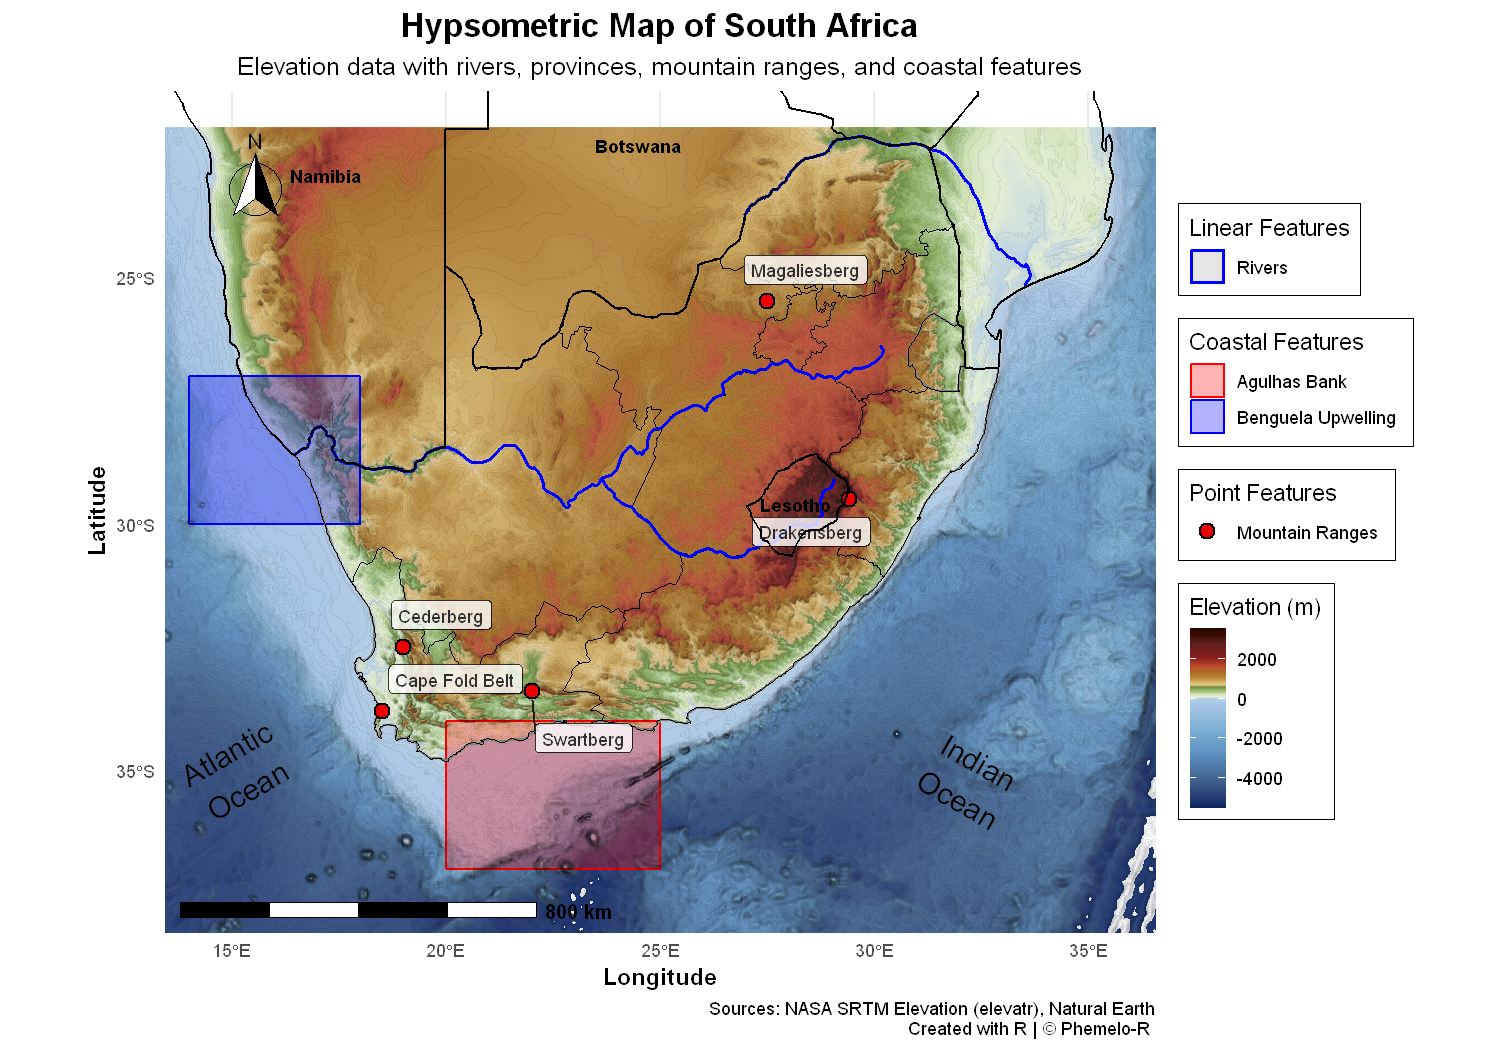

In [18]:
ggplot() +
  # Add hillshade data
  geom_raster(data = hillshade_df, aes(x, y, fill = hillshade)) + 
  scale_fill_gradient(low = "black", high = "white", guide = "none") +
  
  # Add elevation data
  geom_raster(data = elevation_df, aes(x, y, fill = elevation), alpha = 0.9) +
  scale_fill_gradientn(
    colours = hypsometric_colors,
    name = "Elevation (m)",
    values = scales::rescale(c(-5500, 0, 500, 1000, 2000, 3500)), 
    limits = c(-5500, 3500), # Set limits for elevation
    na.value = "transparent"
  ) +
  
  # Add coastal features
  new_scale_fill() + # Add a new scale for fill
  
  geom_polygon(data = agulhas_bank, aes(x, y, fill = "Agulhas Bank"), alpha = 0.3, color = "red") +
  geom_polygon(data = benguela_upwelling, aes(x, y, fill = "Benguela Upwelling"), alpha = 0.3, color = "blue") + 
  scale_fill_manual(name = "Coastal Features", values = c("Agulhas Bank" = "red", "Benguela Upwelling" = "blue")) +
  
  # Add contours and borders
  geom_contour(data = elevation_df, aes(x, y, z = elevation), color = "black", linewidth = 0.1, bins = 200, alpha = 0.08) +
  borders("world", region = "South Africa", fill = NA, color = "black") +
  geom_sf(data = sa_prov, fill = NA, color = "black", size = 0.5) +
  
  # Add hydrographic features
  geom_sf(data = sa_rivers, aes(color = "Rivers"), linewidth = 0.7) +
  scale_color_manual(
    name = "Linear Features",
    values = c("Rivers" = "blue"),
    guide = guide_legend(
      override.aes = list(
        Rivers = list(linetype = "solid")
      )
    )
  ) +
  
  # Add mountain ranges and their labels
  geom_point(data = mountain_ranges, aes(lon, lat, shape = "Mountain Ranges"), color = "black", size = 3, stroke = 1, fill = "red2") +
  geom_label_repel(data = mountain_ranges, aes(lon, lat, label = name), color = "black", size = 3, box.padding = 0.5, point.padding = 0.5,
                   min.segment.length = 0.8, segment.color = "black", alpha = 0.8, fill = "white") +
  scale_shape_manual(
    name = "Point Features",
    values = c("Mountain Ranges" = 21),
    guide = guide_legend(override.aes = list(fill = "red2", size = 3))
  ) +
  
  # Add neighboring countries and their labels
  geom_sf(data = neighboring_countries, fill = NA, color = "black", linewidth = 0.5) +
  geom_sf_text(data = neighboring_countries, aes(label = name), color = "black", size = 3, fontface = "bold") +
  
  # Add labels for oceans
  annotate("text", label = "Atlantic\nOcean", x = 15.1, y = -35.0, size = 5.0, angle = 30, colour = "black") + 
  annotate("text", label = "Indian\nOcean", x = 32.2, y = -35.2, size = 5.0, angle = 330, colour = "black") +
  
  # Set coordinate system limits
  coord_sf(xlim = c(xmin, xmax), ylim = c(ymin, ymax)) +
  
  # Add theme and labels
  theme_minimal() + 
  labs(
    title = "Hypsometric Map of South Africa", 
    subtitle = "Elevation data with rivers, provinces, mountain ranges, and coastal features", 
    caption = "Sources: NASA SRTM Elevation (elevatr), Natural Earth\nCreated with R | © Phemelo-R ", 
    x = "Longitude", y = "Latitude"
  ) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    plot.subtitle = element_text(hjust = 0.5, size = 12),
    legend.position = "right",
    legend.justification = "left", 
    legend.background = element_rect(fill = "white", color = "black", linewidth = 0.2),
    legend.box = "vertical",
    axis.title = element_text(face = "bold")
  ) +
  
  # Add map elements: scale bar and north arrow
  annotation_scale(
    location = "bl",
    width_hint = 0.4,
    bar_cols = c("black", "white"),
    line_width = 1,
    text_cex = 0.8,
    text_face = "bold",
    tick_height = 0.6
  ) +
  annotation_north_arrow(
    location = "tl",
    which_north = "true",
    pad_x = unit(0.3, "in"),
    pad_y = unit(0.3, "in"),
    style = north_arrow_fancy_orienteering
  )

#### *This brings an end to our map making. You can play around with the code and even add shapefiles to your maps to make them better.*